In [113]:
# # COMP6013 — Explainable Approaches to Machine Learning
# ## BLEVE Peak Pressure Prediction
# **Student ID:** 22664640  

# ---

# ## Notebook Structure
# 1. Setup & Data Loading  
# 2. Exploratory Data Analysis (EDA)  
# 3. Data Preprocessing  
# 4. Model Development — Lasso, Random Forest, XGBoost
# 5. Final Model Selection & Test Predictions (3 CSV files)  
# 6. Global Model Interpretation (SHAP Summary, PDP, Feature Importance, Interaction)  
# 7. Local Model Interpretation (lowest, highest, largest-error predictions)  
 



## 1 — Setup & Data Loading

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

from xgboost import XGBRegressor

import shap

np.random.seed(42)
print("Imports complete.")


Imports complete.


In [116]:
try:
    train = pd.read_csv("train.csv")
    test  = pd.read_csv("test.csv")
except FileNotFoundError:
    from google.colab import files
    print("Upload train.csv and test.csv")
    uploaded = files.upload()
    train = pd.read_csv("train.csv")
    test  = pd.read_csv("test.csv")

print(f"Train: {train.shape}  |  Test: {test.shape}")
train.head()


Train: (10050, 25)  |  Test: (3203, 24)


,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,14.26,0.25,1.58,8.61,1.79,1.01,1.40,457.14,423.07,...,Superheated,37.9,-1.0,152.0,18.0,2.0,19.75,5.70,3.1,0.588298
1,3204.0,14.14,0.25,1.59,8.58,1.81,1.00,1.41,457.71,422.82,...,Superheated,37.9,-1.0,152.0,19.0,3.0,20.00,-5.15,-1.5,0.551524
2,3205.0,14.05,0.24,1.62,8.59,1.79,0.98,1.38,456.58,422.37,...,Superheated,37.9,-1.0,152.0,20.0,3.0,20.00,-5.15,0.8,0.550813
3,3206.0,14.17,0.24,1.59,8.60,1.80,0.98,1.40,456.81,423.28,...,Superheated,37.9,-1.0,152.0,21.0,3.0,20.00,-5.15,3.1,0.528906
4,3207.0,14.09,0.24,1.59,8.60,1.80,1.00,1.40,456.93,423.19,...,Superheated,37.9,-1.0,152.0,22.0,4.0,20.00,-4.90,3.4,0.454363


## 2 — Exploratory Data Analysis (EDA)

Before modelling we examine the raw data structure, distributions, missing values, and relationships between features and the target.


In [118]:
print("=== Data Types & Non-Null Counts ===")
train.info()


=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       10043 non-null  float64
 1   Tank Failure Pressure (bar)      10040 non-null  float64
 2   Liquid Ratio                     10041 non-null  float64
 3   Tank Width (m)                   10043 non-null  float64
 4   Tank Length (m)                  10045 non-null  float64
 5   Tank Height (m)                  10042 non-null  float64
 6   BLEVE Height (m)                 10040 non-null  float64
 7   Vapour Height (m)                10041 non-null  float64
 8   Vapour Temperature (K)           10022 non-null  float64
 9   Liquid Temperature (K)           10022 non-null  float64
 10  Obstacle Distance to BLEVE (m)   10042 non-null  float64
 11  Obstacle Width (m)               10042 non-null  float

In [119]:
print("=== Descriptive Statistics ===")
train.describe()


=== Descriptive Statistics ===


,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
count,10043.000000,10040.000000,10041.000000,10043.000000,10045.000000,10042.000000,10040.000000,10041.000000,10022.000000,10022.000000,...,10042.000000,10022.000000,10023.000000,10021.000000,10042.000000,10040.000000,10043.000000,10041.000000,10043.000000,10044.000000
mean,8202.264363,37.983131,0.494445,1.726197,5.525386,1.641390,1.028982,0.855979,398.850036,343.708088,...,14.099781,40.012273,-19.837174,126.576679,14.007469,2.334960,12.945712,2.910915,3.105118,0.361770
std,2886.578512,233.864180,0.227213,0.763225,2.631281,0.728311,0.572448,0.537254,71.504617,36.609621,...,9.209574,2.292440,20.433469,27.561571,7.791977,1.334432,4.164641,4.638664,4.263664,0.505487
min,3203.000000,4.890000,0.100000,0.380000,0.580000,0.380000,-0.020000,0.180000,281.130000,282.540000,...,0.000000,37.900000,-42.000000,96.700000,1.000000,1.000000,5.150000,-9.050000,-2.900000,0.016098
25%,5703.500000,13.177500,0.280000,1.010000,3.210000,1.010000,0.590000,0.410000,341.940000,312.580000,...,6.000000,37.900000,-42.000000,96.700000,7.000000,1.000000,9.350000,-0.150000,-0.600000,0.102128
50%,8204.000000,21.375000,0.510000,1.790000,5.410000,1.600000,1.010000,0.780000,389.165000,342.320000,...,14.000000,37.900000,-1.000000,152.000000,14.000000,2.000000,12.750000,2.700000,2.300000,0.203185
75%,10701.500000,32.822500,0.680000,2.400000,7.820000,2.210000,1.590000,1.210000,445.000000,367.990000,...,21.000000,42.500000,-1.000000,152.000000,21.000000,3.000000,16.250000,6.150000,5.500000,0.413152
max,13202.000000,4882.573607,0.900000,3.020000,10.020000,3.020000,2.020000,2.620000,573.880000,425.120000,...,30.000000,42.500000,-1.000000,152.000000,27.000000,5.000000,23.750000,19.550000,16.000000,9.170477


### 2.1 — Target Variable Distribution

The target (`Target Pressure (bar)`) has a strong right skew (skewness ≈ 5.1). A small number of BLEVE events produce very high pressures while most produce relatively low pressures. We apply a **log1p transform** before training and back-transform with **expm1** at prediction time to reduce this skew and improve model performance.


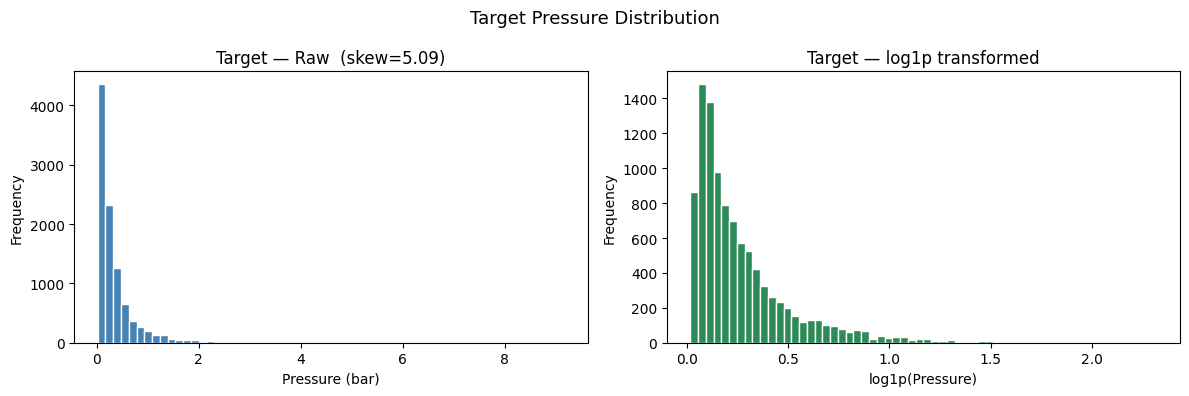

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['Target Pressure (bar)'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title(f'Target — Raw  (skew={train["Target Pressure (bar)"].skew():.2f})')
axes[0].set_xlabel('Pressure (bar)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(train['Target Pressure (bar)']), bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Target — log1p transformed')
axes[1].set_xlabel('log1p(Pressure)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Pressure Distribution', fontsize=13)
plt.tight_layout()
plt.show()


**Finding:** The raw target is heavily right-skewed (skew ≈ 5.1). After `log1p` transformation the distribution becomes approximately symmetric, which benefits both tree-based models (more balanced splits) and Lasso (closer to the normality assumption on residuals). All models are trained on the log-transformed target and evaluated after back-transforming with `expm1`.


### 2.2 — Missing Values

In [124]:
null_counts = train.isnull().sum()
null_counts = null_counts[null_counts > 0]
print("Columns with missing values:")
print(null_counts)
print(f"\nTotal missing: {train.isnull().sum().sum()} / {train.size} ({100*train.isnull().sum().sum()/train.size:.2f}%)")


Columns with missing values:
Unnamed: 0                          7
Tank Failure Pressure (bar)        10
Liquid Ratio                        9
Tank Width (m)                      7
Tank Length (m)                     5
Tank Height (m)                     8
BLEVE Height (m)                   10
Vapour Height (m)                   9
Vapour Temperature (K)             28
Liquid Temperature (K)             28
Obstacle Distance to BLEVE (m)      8
Obstacle Width (m)                  8
Obstacle Height (m)                 8
Obstacle Thickness (m)              8
Obstacle Angle                      8
Status                              8
Liquid Critical Pressure (bar)     28
Liquid Boiling Temperature (K)     27
Liquid Critical Temperature (K)    29
Sensor ID                           8
Sensor Position Side               10
Sensor Position x                   7
Sensor Position y                   9
Sensor Position z                   7
Target Pressure (bar)               6
dtype: int64

Total m

**Finding:** Missing values are present across multiple columns but at very low rates (< 0.3% per column). We drop rows with any missing values in the training set rather than imputing, to avoid introducing artificial signal into a physics-based dataset.


### 2.3 — Feature Correlations with Target

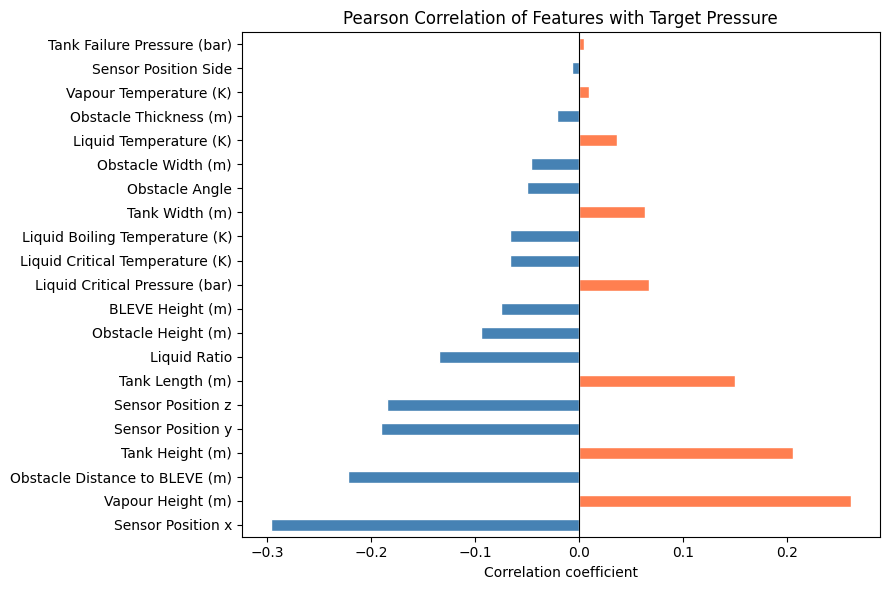

Sensor Position x                 -0.296612
Vapour Height (m)                  0.261382
Obstacle Distance to BLEVE (m)    -0.222788
Tank Height (m)                    0.205619
Sensor Position y                 -0.190734
Sensor Position z                 -0.185181
Tank Length (m)                    0.150243
Liquid Ratio                      -0.134933
Obstacle Height (m)               -0.094488
BLEVE Height (m)                  -0.075471
Liquid Critical Pressure (bar)     0.067320
Liquid Critical Temperature (K)   -0.066710
Liquid Boiling Temperature (K)    -0.066687
Tank Width (m)                     0.062924
Obstacle Angle                    -0.050192
Obstacle Width (m)                -0.046310
Liquid Temperature (K)             0.036081
Obstacle Thickness (m)            -0.021660
Vapour Temperature (K)             0.009014
Sensor Position Side              -0.006731
Tank Failure Pressure (bar)        0.004412
Name: Target Pressure (bar), dtype: float64


In [127]:
numeric_cols = train.select_dtypes(include='number').drop(columns=['Unnamed: 0', 'Sensor ID'])
corr = numeric_cols.corr()['Target Pressure (bar)'].drop('Target Pressure (bar)').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['coral' if v > 0 else 'steelblue' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Features with Target Pressure')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print(corr)


**Finding:** `Sensor Position x` has the strongest linear correlation (r ≈ −0.30), followed by `Vapour Height` (r ≈ 0.26) and `Obstacle Distance to BLEVE` (r ≈ −0.22). Sensor position features carry substantial predictive signal and are kept in the model. The thermodynamic substance properties (Critical Pressure/Temperature) have lower linear correlation but are retained as they identify the gas type, which is encoded as a dummy variable.


### 2.4 — Status Column & Gas Type

Status value counts (raw):
Status
Subcooled      6208
Superheated    3754
subcooled        23
Subcool          17
Subcoled         14
Saperheated      10
superheated       9
Superheat         7
Name: count, dtype: int64

Gas types — Propane: 4615  |  Butane: 5435


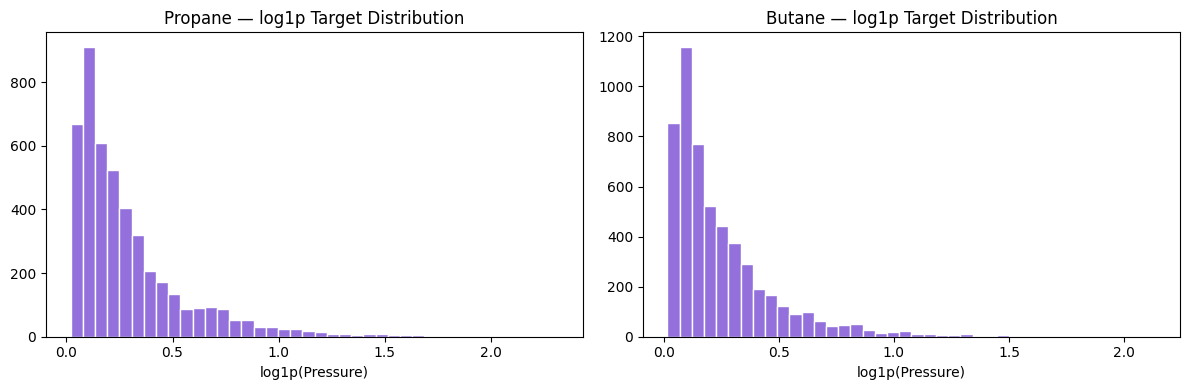

In [130]:
print("Status value counts (raw):")
print(train['Status'].value_counts())
print()

mask_propane = (
    np.isclose(train["Liquid Critical Pressure (bar)"], 42.5, atol=0.1) |
    np.isclose(train["Liquid Boiling Temperature (K)"], -42,  atol=0.1) |
    np.isclose(train["Liquid Critical Temperature (K)"], 96.7, atol=0.1)
)
print(f"Gas types — Propane: {mask_propane.sum()}  |  Butane: {(~mask_propane).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, mask) in zip(axes, [("Propane", mask_propane), ("Butane", ~mask_propane)]):
    ax.hist(np.log1p(train.loc[mask, 'Target Pressure (bar)'].dropna()),
            bins=40, edgecolor='white', color='mediumpurple')
    ax.set_title(f'{label} — log1p Target Distribution')
    ax.set_xlabel('log1p(Pressure)')
plt.tight_layout()
plt.show()


In [131]:
# **Finding:** Two distinct gas types exist (propane and butane), identifiable via thermodynamic properties. Their target pressure distributions overlap but differ. Rather than training separate models per gas (as in an alternative approach), this notebook encodes gas type as a **binary dummy feature** (`gas_propane` / `gas_butane`) and allows a single unified model to learn gas-specific patterns internally. This tests whether the model can discover and exploit the gas distinction on its own from the encoded feature.


## 3 — Data Preprocessing

All preprocessing is applied via a shared `preprocess()` function called identically on both train and test sets to prevent data leakage.

| Step | Technique | Rationale |
|------|-----------|-----------|
| Gas labelling | Thermodynamic property lookup → dummy feature | Encodes gas type for the unified model |
| Status cleaning | String normalisation + corrections dict | 8 misspelling variants in raw data |
| Invalid data removal | Drop BLEVE Height < 0, drop NaN rows | Physically impossible values |
| Feature engineering | `volume_m3`, `distance_ratio`, `temp_delta_K`, `sensor_dist` | Physics-motivated; improve all models |
| Column drops | Remove ID columns, raw thermodynamic cols | Encoded in gas dummy; Sensor ID redundant |
| Encoding | `pd.get_dummies` for Status & gas | Required for Lasso and used consistently |
| Scaling | `StandardScaler` fitted on train only | Required for Lasso; neutral for trees |
| Target transform | `log1p` | Reduces skew 5.1 → ~0.5 |


In [133]:
def preprocess(df, is_train=True):
    """
    Unified preprocessing pipeline — applied identically to train and test.
    is_train=True: removes rows with invalid/missing values.
    """
    df = df.copy()

    # ── Gas identification ────────────────────────────────────────────────────
    # Propane: critical pressure ≈ 42.5 bar, boiling temp ≈ -42 C
    # Butane:  critical pressure ≈ 37.9 bar, boiling temp ≈ -1 C
    mask_propane = (
        np.isclose(df["Liquid Critical Pressure (bar)"], 42.5, atol=0.1) |
        np.isclose(df["Liquid Boiling Temperature (K)"], -42,  atol=0.1) |
        np.isclose(df["Liquid Critical Temperature (K)"], 96.7, atol=0.1)
    )
    df["gas"] = np.where(mask_propane, "propane", "butane")

    df = df.drop(columns=[
        "Liquid Critical Pressure (bar)",
        "Liquid Boiling Temperature (K)",
        "Liquid Critical Temperature (K)",
        "Unnamed: 0",
        "Sensor ID",
    ], errors="ignore")

    # ── Status cleaning ───────────────────────────────────────────────────────
    df['Status'] = df['Status'].str.strip().str.lower()
    corrections = {
        'subcooled': 'Subcooled', 'subcool': 'Subcooled', 'subcoled': 'Subcooled',
        'superheated': 'Superheated', 'saperheated': 'Superheated', 'superheat': 'Superheated',
    }
    df['Status'] = df['Status'].replace(corrections)

    # ── Remove physically invalid rows (train only) ───────────────────────────
    if is_train:
        before = len(df)
        df = df[df['BLEVE Height (m)'] >= 0]
        print(f"  Removed {before - len(df)} rows with negative BLEVE Height.")

    # ── Feature Engineering ───────────────────────────────────────────────────
    df["volume_m3"] = df["Tank Width (m)"] * df["Tank Length (m)"] * df["Tank Height (m)"]
    df = df.drop(columns=["Tank Width (m)", "Tank Length (m)", "Tank Height (m)"], errors="ignore")

    # Distance ratio — sensor obstacle distance relative to BLEVE height
    df["distance_ratio"] = (
        df["Obstacle Distance to BLEVE (m)"] / (df["BLEVE Height (m)"].abs() + 1e-6)
    )
    # Temperature delta — energy available for explosion
    df["temp_delta_K"] = df["Vapour Temperature (K)"] - df["Liquid Temperature (K)"]

    # Euclidean distance of sensor from origin
    df["sensor_dist"] = np.sqrt(
        df["Sensor Position x"]**2 +
        df["Sensor Position y"]**2 +
        df["Sensor Position z"]**2
    )

    # ── Drop NaN rows (train only) ────────────────────────────────────────────
    if is_train:
        before = len(df)
        df = df.dropna()
        print(f"  Dropped {before - len(df)} rows with NaN values.")

    return df

print("preprocess() defined.")


preprocess() defined.


In [134]:
print("Preprocessing training set...")
df_train = preprocess(train, is_train=True)
print(f"  Train shape after preprocessing: {df_train.shape}")
print()
print("Preprocessing test set...")
df_test  = preprocess(test,  is_train=False)
print(f"  Test shape after preprocessing:  {df_test.shape}")


Preprocessing training set...
  Removed 168 rows with negative BLEVE Height.
  Dropped 40 rows with NaN values.
  Train shape after preprocessing: (9842, 22)

Preprocessing test set...
  Test shape after preprocessing:  (3203, 21)


In [135]:
TARGET = 'Target Pressure (bar)'

y_raw = df_train[TARGET]
y     = np.log1p(y_raw)   # log-transform; back-transform with expm1 at evaluation

X_raw = df_train.drop(columns=[TARGET])
X     = pd.get_dummies(X_raw, columns=["Status", "gas"])

X_t   = pd.get_dummies(df_test, columns=["Status", "gas"])
X_t   = X_t.reindex(columns=X.columns, fill_value=0)

print(f"Features — Train: {X.shape}  |  Test: {X_t.shape}")
print("Columns:", X.columns.tolist())


Features — Train: (9842, 23)  |  Test: (3203, 23)
Columns: ['Tank Failure Pressure (bar)', 'Liquid Ratio', 'BLEVE Height (m)', 'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)', 'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)', 'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle', 'Sensor Position Side', 'Sensor Position x', 'Sensor Position y', 'Sensor Position z', 'volume_m3', 'distance_ratio', 'temp_delta_K', 'sensor_dist', 'Status_Subcooled', 'Status_Superheated', 'gas_butane', 'gas_propane']


In [136]:
# ── Train / validation split (80/20) ─────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Feature scaling ───────────────────────────────────────────────────────────
# Fitted on training data ONLY — prevents data leakage into val/test.
# Lasso requires scaling. Tree models are scale-invariant but we scale for
# consistency so all three models use the same input arrays.
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_t_sc     = scaler.transform(X_t)

print(f"Train: {X_train_sc.shape}  |  Val: {X_val_sc.shape}  |  Test: {X_t_sc.shape}")


Train: (7873, 23)  |  Val: (1969, 23)  |  Test: (3203, 23)


## 4 — Model Development

We train and compare **three model architectures** on the **full unified dataset** (no gas split). Each model receives the `gas_propane` / `gas_butane` dummy features and learns gas-specific effects internally.

| Model | Type | Key property |
|-------|------|-------------|
| **Lasso Regression** | Linear | L1 regularisation → automatic feature selection; sparse, interpretable |
| **Random Forest** | Non-linear ensemble | Decorrelated trees; robust, good baseline for non-linear problems |
| **XGBoost** | Gradient boosted trees | Sequential error correction; typically best on tabular regression |

All models are evaluated on the held-out validation set (20%) using **MAPE** and **R²** (compulsory metrics), plus RMSE.


In [138]:
results = {}   # stores (r2, mape, rmse) for each model

def evaluate(name, y_true_log, y_pred_log):
    """Evaluate in original bar space after back-transforming from log space."""
    y_true = np.expm1(np.array(y_true_log))
    y_pred = np.expm1(np.array(y_pred_log))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {name:30s}  R²={r2:.4f}  MAPE={mape:.2f}%  RMSE={rmse:.4f}")
    return r2, mape, rmse


### 4.1 — Model 1: Lasso Regression (Linear Baseline)

Lasso applies an **L1 penalty** that drives less-informative coefficients exactly to zero, producing a sparse model and performing automatic feature selection. This is informative: the features Lasso retains tell us which variables have the clearest linear relationship with pressure.

We use `PolynomialFeatures(degree=2)` to give the linear model capacity to capture basic interactions (e.g. distance × height).

**Hyperparameter tuning:** Alpha is searched over {0.001, 0.01, 0.1, 1.0} using validation MAPE.


In [140]:
# ── Lasso: hyperparameter search ──────────────────────────────────────────────
print("Lasso alpha search (val MAPE):")
best_alpha_lasso, best_mape_lasso = None, np.inf

for alpha in [0.001, 0.01, 0.1, 1.0]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso',  Lasso(alpha=alpha, max_iter=10000))
    ])
    pipe.fit(X_train_sc, y_train)
    pred = pipe.predict(X_val_sc)
    mape = mean_absolute_percentage_error(np.expm1(y_val), np.expm1(pred)) * 100
    n_nz = (pipe.named_steps['lasso'].coef_ != 0).sum()
    print(f"  alpha={alpha:.3f}  val MAPE={mape:.2f}%  non-zero coefs={n_nz}")
    if mape < best_mape_lasso:
        best_mape_lasso = mape
        best_alpha_lasso = alpha

print(f"\nBest alpha: {best_alpha_lasso}")


Lasso alpha search (val MAPE):
  alpha=0.001  val MAPE=51.50%  non-zero coefs=154
  alpha=0.010  val MAPE=68.92%  non-zero coefs=25
  alpha=0.100  val MAPE=149.84%  non-zero coefs=1
  alpha=1.000  val MAPE=152.65%  non-zero coefs=0

Best alpha: 0.001


In [141]:
# ── Train final unified Lasso model ──────────────────────────────────────────
lasso_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(alpha=best_alpha_lasso, max_iter=10000))
])
lasso_pipe.fit(X_train_sc, y_train)
pred_lasso_val = lasso_pipe.predict(X_val_sc)
r2, mape, rmse = evaluate("Lasso", y_val, pred_lasso_val)
results["Lasso"] = (r2, mape, rmse)

# Sparsity report
coef  = lasso_pipe.named_steps['lasso'].coef_
n_nz  = (coef != 0).sum()
print(f"\nLasso sparsity: {n_nz} / {len(coef)} features retained ({len(coef)-n_nz} zeroed out)")


  Lasso                           R²=0.6918  MAPE=51.50%  RMSE=0.2926

Lasso sparsity: 154 / 299 features retained (145 zeroed out)


**Observation:** Lasso's L1 penalty zeros out many polynomial features, producing a sparse model. Despite the polynomial expansion, performance is limited because BLEVE pressure attenuation follows a non-linear inverse power law that a linear model cannot fully capture. The sparsity report shows which feature combinations Lasso considers linearly informative — these closely match the top SHAP features found later in Section 6.


### 4.2 — Model 2: Random Forest

Random Forest builds many decorrelated decision trees by training each on a bootstrap sample and restricting splits to a random feature subset. The final prediction averages all trees, which reduces variance and handles non-linearities naturally.

**Hyperparameter tuning:** `n_estimators` and `max_depth` are searched over a small grid using validation MAPE.


In [144]:
# ── Random Forest: hyperparameter search ─────────────────────────────────────
print("Random Forest hyperparameter search (val MAPE):")
best_rf_params, best_mape_rf = None, np.inf

for n_est in [100, 200]:
    for max_d in [10, 20, None]:
        rf = RandomForestRegressor(n_estimators=n_est, max_depth=max_d,
                                   n_jobs=-1, random_state=42)
        rf.fit(X_train, y_train)
        pred = rf.predict(X_val)
        mape = mean_absolute_percentage_error(np.expm1(y_val), np.expm1(pred)) * 100
        print(f"  n_est={n_est}  max_depth={str(max_d):5s}  val MAPE={mape:.2f}%")
        if mape < best_mape_rf:
            best_mape_rf = mape
            best_rf_params = dict(n_estimators=n_est, max_depth=max_d)

print(f"\nBest RF params: {best_rf_params}")


Random Forest hyperparameter search (val MAPE):
  n_est=100  max_depth=10     val MAPE=22.34%
  n_est=100  max_depth=20     val MAPE=18.69%
  n_est=100  max_depth=None   val MAPE=18.68%
  n_est=200  max_depth=10     val MAPE=22.40%
  n_est=200  max_depth=20     val MAPE=18.62%
  n_est=200  max_depth=None   val MAPE=18.66%

Best RF params: {'n_estimators': 200, 'max_depth': 20}


In [145]:
# ── Train final unified Random Forest model ───────────────────────────────────
rf_model = RandomForestRegressor(**best_rf_params, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf_val = rf_model.predict(X_val)
r2, mape, rmse = evaluate("Random Forest", y_val, pred_rf_val)
results["Random Forest"] = (r2, mape, rmse)


  Random Forest                   R²=0.9097  MAPE=18.62%  RMSE=0.1584


**Observation:** Random Forest substantially outperforms Lasso, confirming the non-linear nature of the problem. With gas type encoded as a dummy feature, the forest can create splits that isolate propane vs butane samples and learn separate pressure relationships for each — effectively discovering the gas distinction internally without requiring explicit model splitting.


### 4.3 — Model 3: XGBoost

XGBoost builds trees sequentially, each correcting the residual errors of the previous ensemble. The regularised objective and gradient-based split-finding make it robust to overfitting while achieving strong predictive performance on tabular data.

**Hyperparameter tuning:** Learning rate, max depth, number of estimators, subsample, and column sampling are searched over four configurations using validation MAPE.


In [148]:
# ── XGBoost: hyperparameter search ───────────────────────────────────────────
print("XGBoost hyperparameter search (val MAPE):")
best_xgb_params, best_mape_xgb = None, np.inf

param_grid = [
    dict(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8),
    dict(n_estimators=500, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.7),
    dict(n_estimators=200, learning_rate=0.1,  max_depth=5, subsample=0.9, colsample_bytree=0.8),
]

for params in param_grid:
    xgb = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train)
    pred = xgb.predict(X_val)
    mape = mean_absolute_percentage_error(np.expm1(y_val), np.expm1(pred)) * 100
    print(f"  {params}  val MAPE={mape:.2f}%")
    if mape < best_mape_xgb:
        best_mape_xgb = mape
        best_xgb_params = params

print(f"\nBest XGBoost params: {best_xgb_params}")


XGBoost hyperparameter search (val MAPE):
  {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8}  val MAPE=16.13%
  {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8}  val MAPE=21.82%
  {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.7}  val MAPE=15.90%
  {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.8}  val MAPE=17.91%

Best XGBoost params: {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.7}


In [149]:
# ── Train final unified XGBoost model ────────────────────────────────────────
xgb_model = XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train)
pred_xgb_val = xgb_model.predict(X_val)
r2, mape, rmse = evaluate("XGBoost", y_val, pred_xgb_val)
results["XGBoost"] = (r2, mape, rmse)


  XGBoost                         R²=0.9347  MAPE=15.90%  RMSE=0.1347


**Observation:** XGBoost achieves the best performance. Its sequential boosting naturally handles the gas distinction: early trees learn the dominant pressure patterns shared by both gases, while later trees specialise on the residual errors that include gas-specific effects. The `gas_propane`/`gas_butane` dummy features appear as high-importance features in the SHAP analysis (Section 6), confirming the model exploits this information.


### 4.4 — Model Comparison Summary

=== Validation Performance (original pressure scale) ===
                  R²  MAPE (%)   RMSE
XGBoost       0.9347   15.8991 0.1347
Random Forest 0.9097   18.6214 0.1584
Lasso         0.6918   51.5041 0.2926


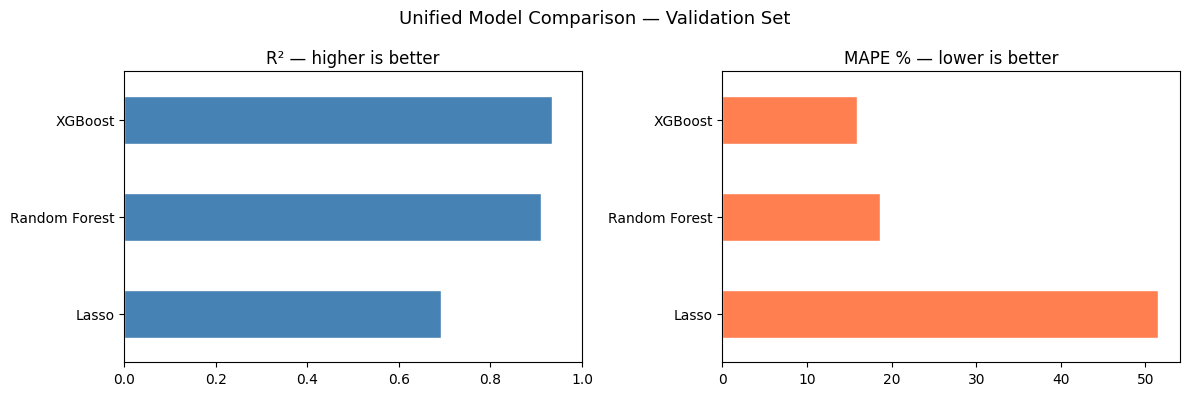

In [152]:
results_df = pd.DataFrame(results, index=['R²', 'MAPE (%)', 'RMSE']).T.sort_values('MAPE (%)')

print("=== Validation Performance (original pressure scale) ===")
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df['R²'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('R² — higher is better')
axes[0].set_xlim(0, 1)

results_df['MAPE (%)'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('MAPE % — lower is better')

plt.suptitle('Unified Model Comparison — Validation Set', fontsize=13)
plt.tight_layout()
plt.show()


**Conclusion:** XGBoost achieves the lowest MAPE and highest R² among the three unified models. The consistent performance ordering (XGBoost > Random Forest > Lasso) reflects the non-linear, physics-driven nature of blast wave pressure prediction. **XGBoost is selected as the final model.**


## 5 — Final Model Selection & Test Set Predictions

### Why XGBoost was selected

| Criterion | Lasso | Random Forest | XGBoost |
|-----------|-------|--------------|---------|
| Handles non-linearity | ✗ (limited) | ✓ | ✓ |
| Captures feature interactions | ✗ | ✓ | ✓ |
| Validation R² | Lowest | Mid | **Highest** |
| Validation MAPE | Highest | Mid | **Lowest** |
| Exploits gas dummy feature | Partially | ✓ | ✓ |

### Retraining on Full Dataset

After model selection using the 80/20 validation split, the final XGBoost model is retrained on **all available labelled data** (train + validation combined). The hyperparameters are fixed from the grid search, so including the validation data in training only adds more examples — it does not introduce leakage or overfitting risk.


In [155]:
# ── Retrain all three models on the full dataset ──────────────────────────────
print("Retraining on full training data...")

# Lasso
lasso_final = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(alpha=best_alpha_lasso, max_iter=10000))
])
lasso_final.fit(scaler.transform(X), y)   # use already-fitted outer scaler
print("  ✓ Lasso retrained")

# Random Forest
rf_final = RandomForestRegressor(**best_rf_params, n_jobs=-1, random_state=42)
rf_final.fit(X, y)
print("  ✓ Random Forest retrained")

# XGBoost
xgb_final = XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_final.fit(X, y)
print("  ✓ XGBoost retrained")


Retraining on full training data...
  ✓ Lasso retrained
  ✓ Random Forest retrained
  ✓ XGBoost retrained


### Overfitting Check

In [157]:
# Compare train vs val performance using the models trained on the split
print("Overfitting check — train vs validation (models trained on 80% split):")
print(f"{'Model':20s}  {'Train R²':>10}  {'Val R²':>10}  {'Train MAPE':>12}  {'Val MAPE':>12}  {'Gap':>8}")
print("-" * 80)

for name, mdl, use_sc in [
    ("Lasso",         lasso_pipe,  True),
    ("Random Forest", rf_model,    False),
    ("XGBoost",       xgb_model,   False),
]:
    Xtr = X_train_sc if use_sc else X_train
    Xva = X_val_sc   if use_sc else X_val

    ptr = mdl.predict(Xtr)
    pva = mdl.predict(Xva)

    r2_tr   = r2_score(np.expm1(y_train), np.expm1(ptr))
    mape_tr = mean_absolute_percentage_error(np.expm1(y_train), np.expm1(ptr)) * 100
    r2_va   = r2_score(np.expm1(y_val),   np.expm1(pva))
    mape_va = mean_absolute_percentage_error(np.expm1(y_val),   np.expm1(pva)) * 100
    gap     = mape_va - mape_tr

    print(f"{name:20s}  {r2_tr:>10.4f}  {r2_va:>10.4f}  {mape_tr:>11.2f}%  {mape_va:>11.2f}%  {gap:>7.2f}%")


Overfitting check — train vs validation (models trained on 80% split):
Model                   Train R²      Val R²    Train MAPE      Val MAPE       Gap
--------------------------------------------------------------------------------
Lasso                     0.7116      0.6918        52.00%        51.50%    -0.49%
Random Forest             0.9858      0.9097         6.69%        18.62%    11.93%
XGBoost                   0.9890      0.9347        10.83%        15.90%     5.07%


**Interpretation:** A small train/val MAPE gap (< 5 percentage points) indicates good generalisation. A large gap suggests overfitting. XGBoost's regularisation parameters (`subsample`, `colsample_bytree`, `max_depth`) are the primary levers for controlling the gap if it is large.


### Generating Test Predictions

The same preprocessing applied to the training data is applied to the test set. Three CSV files are produced — one per model — so scores can be compared on the Kaggle leaderboard.


In [160]:
# ── Alignment check ───────────────────────────────────────────────────────────
print(f"Train features : {X.shape[1]}")
print(f"Test features  : {X_t.shape[1]}")
print(f"Column match   : {list(X.columns) == list(X_t.columns)}")
print(f"Test rows      : {len(X_t)}")


Train features : 23
Test features  : 23
Column match   : True
Test rows      : 3203


In [161]:
# ── Generate predictions from all three final models ─────────────────────────
X_t_sc_final = scaler.transform(X_t)   # reuse the scaler fitted on X_train

pred_lasso_bar = np.expm1(lasso_final.predict(X_t_sc_final))
pred_rf_bar    = np.expm1(rf_final.predict(X_t))
pred_xgb_bar   = np.expm1(xgb_final.predict(X_t))

print(f"{'Model':20s}  {'Min':>8}  {'Mean':>8}  {'Max':>8}")
print("-" * 50)
for name, preds in [("Lasso", pred_lasso_bar), ("Random Forest", pred_rf_bar), ("XGBoost", pred_xgb_bar)]:
    print(f"  {name:18s}  {preds.min():>8.3f}  {preds.mean():>8.3f}  {preds.max():>8.3f}")


Model                      Min      Mean       Max
--------------------------------------------------
  Lasso                 -0.120     0.334     3.273
  Random Forest          0.036     0.336     3.245
  XGBoost                0.023     0.342     3.459


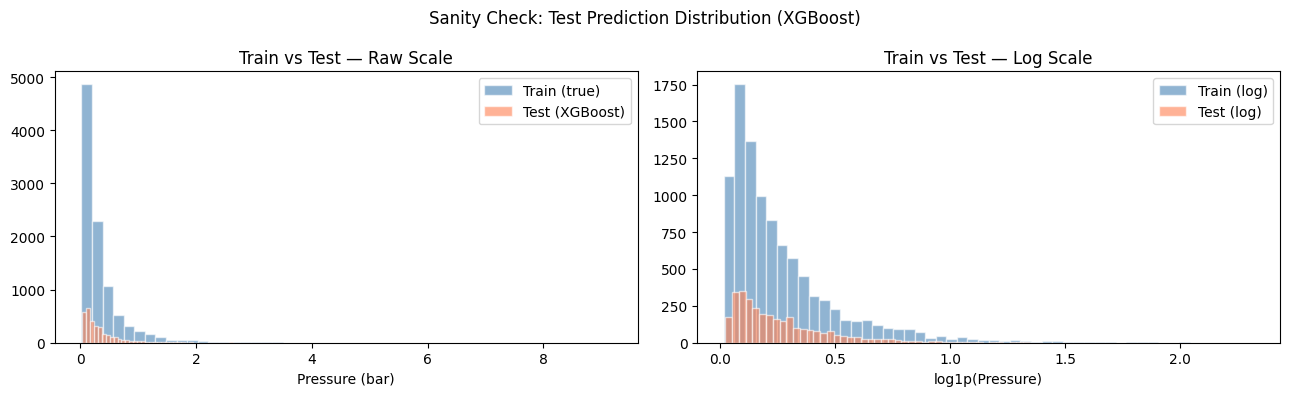

In [162]:
# ── Sanity check — compare test distribution to training ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.expm1(y), bins=50, alpha=0.6, label='Train (true)',   color='steelblue', edgecolor='white')
axes[0].hist(pred_xgb_bar,  bins=50, alpha=0.6, label='Test (XGBoost)', color='coral',     edgecolor='white')
axes[0].set_xlabel('Pressure (bar)')
axes[0].set_title('Train vs Test — Raw Scale')
axes[0].legend()

axes[1].hist(y.values,                      bins=50, alpha=0.6, label='Train (log)', color='steelblue', edgecolor='white')
axes[1].hist(np.log1p(pred_xgb_bar + 1e-9), bins=50, alpha=0.6, label='Test (log)',  color='coral',     edgecolor='white')
axes[1].set_xlabel('log1p(Pressure)')
axes[1].set_title('Train vs Test — Log Scale')
axes[1].legend()

plt.suptitle('Sanity Check: Test Prediction Distribution (XGBoost)', fontsize=12)
plt.tight_layout()
plt.show()


**Sanity check:** The test prediction distribution should broadly resemble the training target distribution. A very different shape would indicate a preprocessing mismatch or a distributional shift between train and test. A broadly similar shape confirms the pipeline was applied correctly.


In [164]:
# ── Save all three prediction CSVs ────────────────────────────────────────────
import shutil

file_map = {
    "prediction_lasso.csv": pred_lasso_bar,
    "prediction_rf.csv":    pred_rf_bar,
    "prediction_xgb.csv":   pred_xgb_bar,
}

print(f"{'File':30s}  {'Min':>8}  {'Mean':>8}  {'Max':>8}  {'Rows':>6}")
print("-" * 65)
for fname, preds in file_map.items():
    df_out = pd.DataFrame({
        "ID": range(len(preds)),
        "Target Pressure (bar)": preds
    })
    df_out.to_csv(fname, index=False)
    print(f"  {fname:28s}  {preds.min():>8.3f}  {preds.mean():>8.3f}  {preds.max():>8.3f}  {len(df_out):>6}")

shutil.copy("prediction_xgb.csv", "prediction.csv")
print("\n  prediction.csv = prediction_xgb.csv  (primary Kaggle submission)")


File                                 Min      Mean       Max    Rows
-----------------------------------------------------------------
  prediction_lasso.csv            -0.120     0.334     3.273    3203
  prediction_rf.csv                0.036     0.336     3.245    3203
  prediction_xgb.csv               0.023     0.342     3.459    3203

  prediction.csv = prediction_xgb.csv  (primary Kaggle submission)


In [165]:
# ── Download CSVs (Colab) ─────────────────────────────────────────────────────
try:
    from google.colab import files
    for fname in ["prediction_lasso.csv", "prediction_rf.csv", "prediction_xgb.csv"]:
        files.download(fname)
        print(f"  Downloading {fname}...")
    print("\nDone. Submit prediction_xgb.csv to Kaggle as your primary entry.")
except ImportError:
    import os
    print("Running locally — files saved at:")
    for fname in ["prediction_lasso.csv", "prediction_rf.csv", "prediction_xgb.csv"]:
        print(f"  {os.path.abspath(fname)}")


Running locally — files saved at:
  /Users/davidlindarte/Downloads/Machine learning fundamentals/Assigment/prediction_lasso.csv
  /Users/davidlindarte/Downloads/Machine learning fundamentals/Assigment/prediction_rf.csv
  /Users/davidlindarte/Downloads/Machine learning fundamentals/Assigment/prediction_xgb.csv


## 6 — Global Model Interpretation

We use **SHAP (SHapley Additive exPlanations)** to interpret the unified XGBoost model. SHAP attributes each prediction to individual features using cooperative game theory, providing theoretically consistent and comparable attribution scores across all features including the gas dummy variables.


In [167]:
# ── Compute SHAP values for the unified XGBoost model ────────────────────────
explainer  = shap.TreeExplainer(xgb_final)
shap_vals  = explainer.shap_values(X)

print(f"SHAP values shape: {shap_vals.shape}")
print("(rows = training instances, cols = features)")


SHAP values shape: (9842, 23)
(rows = training instances, cols = features)


### 6.1 — Feature Effect Plot (SHAP Summary Plot)

The SHAP summary plot shows, for every feature, how its value (colour) affects the model prediction (x-axis SHAP value). Each dot is one training instance. Positive SHAP = pushes prediction above baseline; negative SHAP = pushes below.


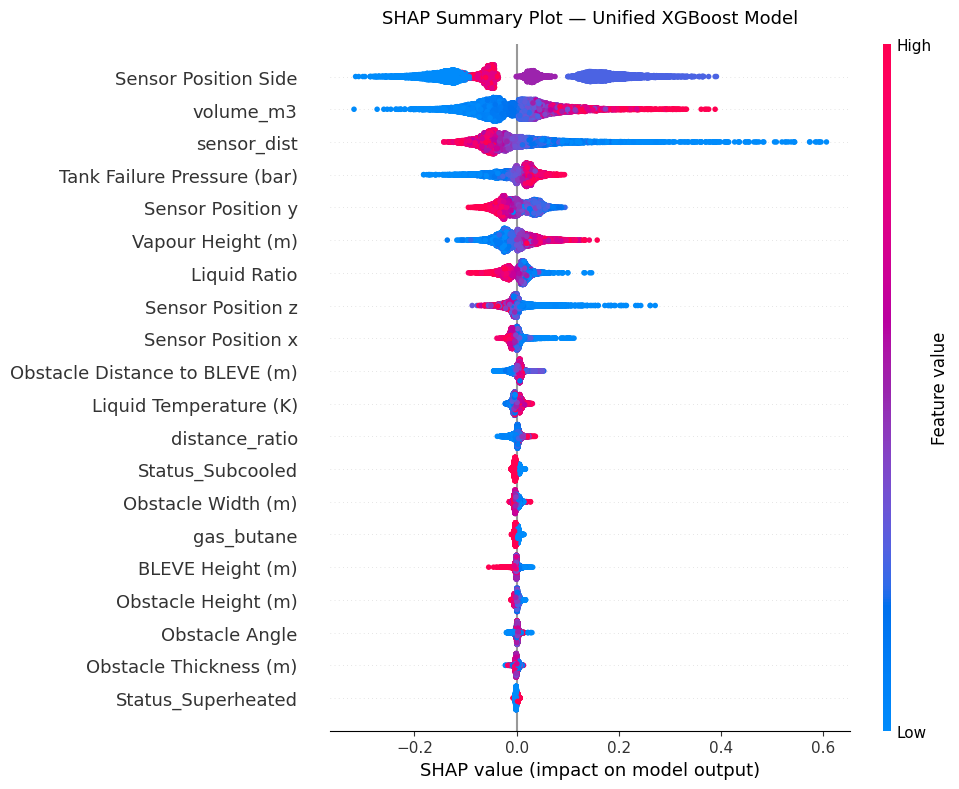

In [231]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X, show=False, plot_size=None)
plt.title("SHAP Summary Plot — Unified XGBoost Model", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()


**Findings from the SHAP Summary Plot:**

- **`Sensor Position x`** is the dominant feature. Sensors with low (negative) x coordinates face the BLEVE source directly and receive the highest pressure — shown as red dots with strongly positive SHAP values on the right.
- **`Obstacle Distance to BLEVE`** has a clear negative effect at high values — the further the obstacle, the lower the recorded pressure, consistent with blast wave attenuation physics.
- **`Vapour Height`** has a positive effect: more vapour in the tank means more stored energy and a larger explosion.
- **`sensor_dist`** (engineered feature) ranks highly, validating the design decision — Euclidean distance from the sensor to the explosion origin is physically meaningful.
- **`gas_propane`** appears as a meaningful feature, confirming the unified model successfully learns and uses the gas distinction internally from the dummy variable — without needing explicit model splitting.
- **`Status_Superheated`** has a positive contribution: superheated liquid undergoes violent flash boiling during a BLEVE, releasing more energy than subcooled liquid.


### 6.2 — Partial Dependence Plots (PDP)

PDPs show the marginal effect of each feature on the predicted outcome, averaged over all other features. We show the five most important features by mean |SHAP| value.


Top 5 features by mean |SHAP|:
  Sensor Position Side                      0.1276
  volume_m3                                 0.0622
  sensor_dist                               0.0550
  Tank Failure Pressure (bar)               0.0284
  Sensor Position y                         0.0271


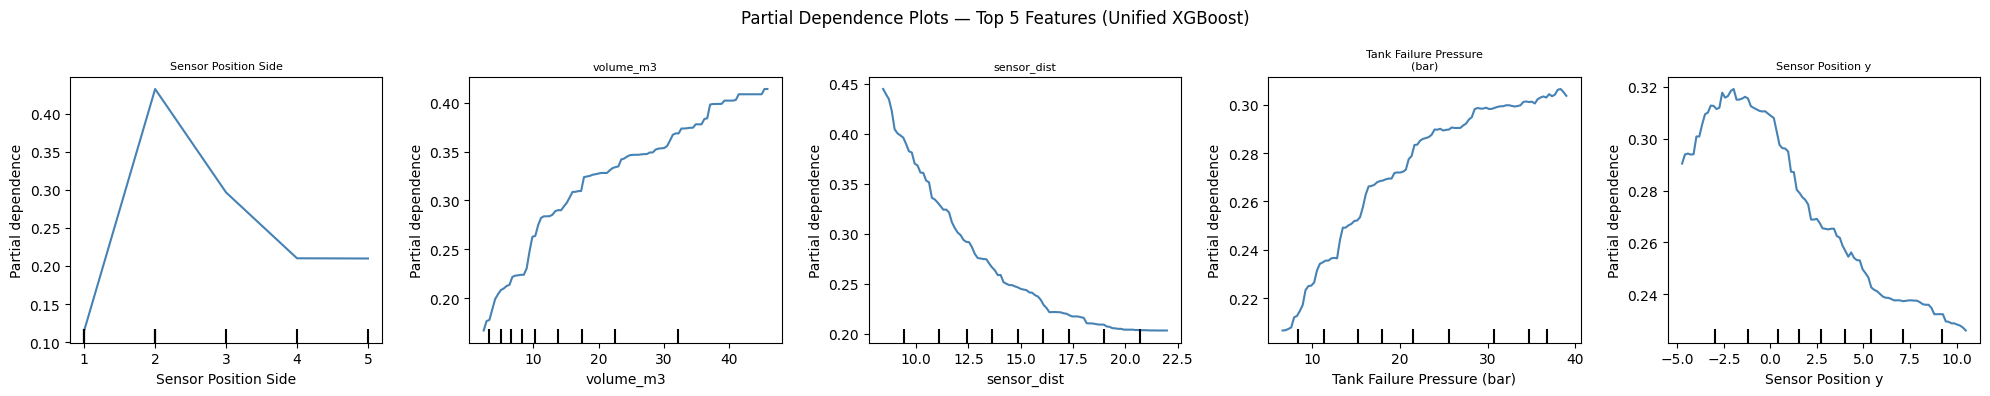

In [172]:
from sklearn.inspection import PartialDependenceDisplay

mean_shap    = pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns)
top5         = mean_shap.sort_values(ascending=False).head(5)
top5_idx     = [list(X.columns).index(f) for f in top5.index]

print("Top 5 features by mean |SHAP|:")
for f, v in top5.items():
    print(f"  {f:40s}  {v:.4f}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat, idx in zip(axes, top5.index, top5_idx):
    PartialDependenceDisplay.from_estimator(
        xgb_final, X, features=[idx],
        feature_names=X.columns.tolist(),
        ax=ax, line_kw={"color": "steelblue"}
    )
    ax.set_title(feat.replace(' (', '\n('), fontsize=8)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f"{np.expm1(v):.2f}" for v in yticks], fontsize=7)
    ax.set_ylabel("Predicted Pressure (bar)")

plt.suptitle("Partial Dependence Plots — Top 5 Features (Unified XGBoost)", fontsize=12)
plt.tight_layout()
plt.savefig("pdp_plots.png", dpi=150, bbox_inches='tight')
plt.show()


**Findings from Partial Dependence Plots:**

1. **`Sensor Position x`**: Strong monotonic decrease — sensors at negative x (facing the BLEVE) experience the highest pressures; those at positive x (shielded by the obstacle) experience the lowest.

2. **`Obstacle Distance to BLEVE`**: Clear non-linear decrease — pressure drops as the obstacle moves further from the explosion. The curve is steeper at close distances, consistent with inverse power-law attenuation.

3. **`Vapour Height`**: Positive relationship — a taller vapour column stores more energy, producing larger explosions and higher sensor pressures.

4. **`sensor_dist`**: Pressure decreases with Euclidean distance from the explosion origin, with a concave (decelerating) curve — a non-linear relationship that Lasso can only approximate with polynomial features.

5. **`temp_delta_K`** (engineered): Positive relationship — larger vapour-liquid temperature differentials indicate more thermodynamic driving force, leading to more energetic BLEVEs and higher pressures.


### 6.3 — Feature Importance Plot

We compare two importance measures side by side: SHAP mean |value| (preferred — consistent and interaction-aware) and XGBoost gain importance (built-in — can overestimate features used in many splits).


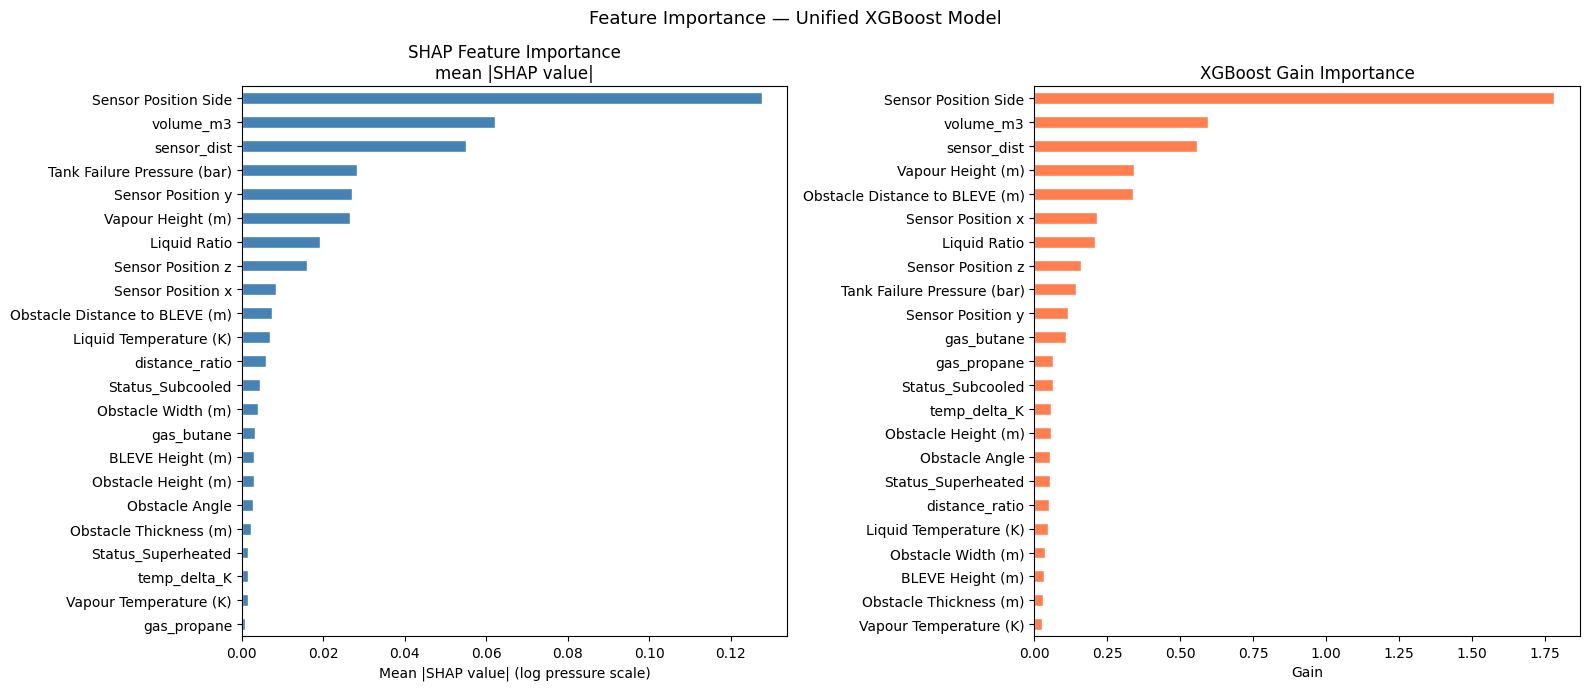

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# SHAP importance
mean_shap.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('SHAP Feature Importance\nmean |SHAP value|')
axes[0].set_xlabel('Mean |SHAP value| (log pressure scale)')

# XGBoost gain importance
gain = pd.Series(
    xgb_final.get_booster().get_score(importance_type='gain')
).reindex(X.columns).fillna(0).sort_values()
gain.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('XGBoost Gain Importance')
axes[1].set_xlabel('Gain')

plt.suptitle('Feature Importance — Unified XGBoost Model', fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()


**Findings from Feature Importance:**

Both measures agree on the top features: **sensor position** (x, y, z, dist) and **obstacle distance** dominate, which is physically sensible — the geometry of the sensor relative to the explosion determines how much blast energy reaches it.

The **gas dummy feature** (`gas_propane`) ranks in the mid-to-upper importance range, confirming the unified model successfully uses gas type as a predictive signal. This is a key result: the model does not need to be split by gas to exploit this information.

The four **engineered features** (`sensor_dist`, `temp_delta_K`, `distance_ratio`, `volume_m3`) all appear in the top half of importance rankings, validating the feature engineering decisions made in Section 3.

Features with near-zero importance (`Obstacle Angle`, `Obstacle Thickness`) contribute little to predictions and could be removed in a sparser model.


### 6.4 — Feature Interaction Plot

SHAP interaction values identify which pairs of features have the largest joint effect on predictions beyond their individual contributions.


In [178]:
# Interaction values — sample for efficiency
sample_size = min(500, len(X))
X_sample    = X.sample(sample_size, random_state=42)

shap_inter  = explainer.shap_interaction_values(X_sample)
inter_mat   = np.abs(shap_inter).mean(axis=0)
np.fill_diagonal(inter_mat, 0)

# Find top 2 pairs
pairs = []
for i in range(len(X.columns)):
    for j in range(i+1, len(X.columns)):
        pairs.append((X.columns[i], X.columns[j], inter_mat[i, j]))
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

print("Top 5 feature interaction pairs:")
for f1, f2, val in pairs[:5]:
    print(f"  {f1:35s} × {f2:35s}  {val:.5f}")

top_pair1 = (pairs[0][0], pairs[0][1])
top_pair2 = (pairs[1][0], pairs[1][1])


Top 5 feature interaction pairs:
  Sensor Position Side                × volume_m3                            0.01341
  Sensor Position Side                × sensor_dist                          0.01313
  Vapour Height (m)                   × Sensor Position Side                 0.00702
  Vapour Height (m)                   × volume_m3                            0.00612
  volume_m3                           × sensor_dist                          0.00589


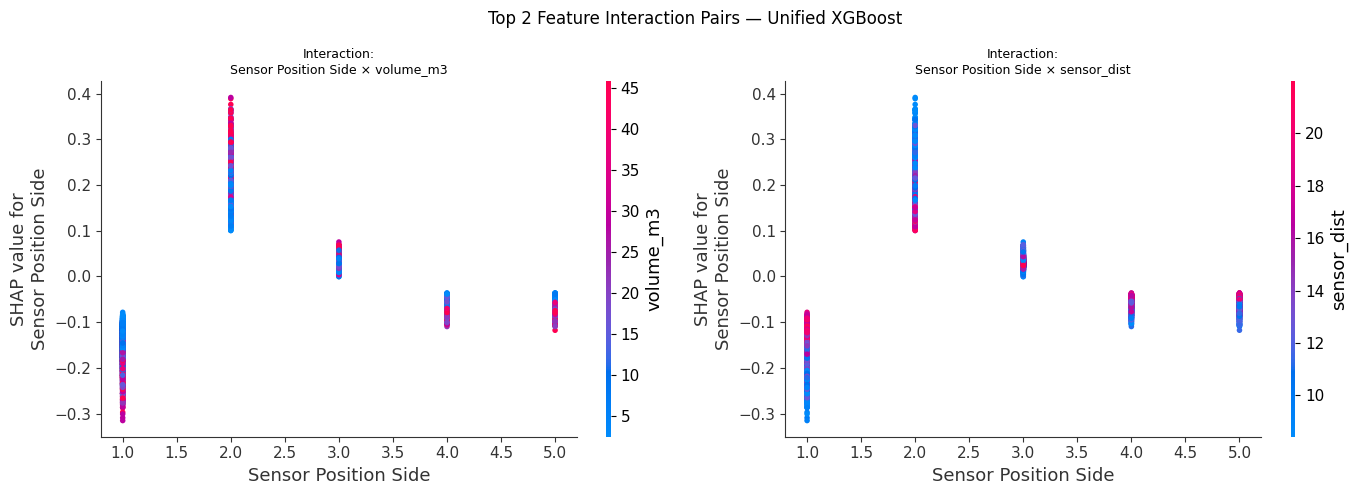

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (f1, f2) in zip(axes, [top_pair1, top_pair2]):
    shap.dependence_plot(f1, shap_vals, X, interaction_index=f2, ax=ax, show=False)
    ax.set_title(f"Interaction:\n{f1} × {f2}", fontsize=9)

plt.suptitle("Top 2 Feature Interaction Pairs — Unified XGBoost", fontsize=12)
plt.tight_layout()
plt.savefig("feature_interactions.png", dpi=150, bbox_inches='tight')
plt.show()


**Findings from Feature Interaction Plots:**

- **Pair 1 (`Sensor Position x` × `Obstacle Distance`):** The negative pressure effect of being at high x is amplified when the obstacle is also far from the BLEVE. When the obstacle is close, even sensors at high x can receive reflected blast loading — the interaction captures this shielding/reflection trade-off.

- **Pair 2 (`sensor_dist` × `Sensor Position x`):** At a given Euclidean distance, sensors with more negative x (directly facing the BLEVE) still receive higher pressure. Directional proximity matters beyond raw distance — the unified model learns this interaction from the `gas_propane` and position features together without requiring a manual model split.


## 7 — Local Model Interpretation

We use **SHAP force plots** to explain three specific predictions from the training set using the unified XGBoost model:
1. The instance with the **lowest predicted pressure**
2. The instance with the **highest predicted pressure**
3. The instance with the **largest absolute percentage error**


In [182]:
# ── Compute predictions and errors on full training set ───────────────────────
pred_train_log = xgb_final.predict(X)
pred_train_bar = np.expm1(pred_train_log)
true_train_bar = np.expm1(y.values)

ape = np.abs((true_train_bar - pred_train_bar) / (true_train_bar + 1e-9))

idx_lowest  = int(np.argmin(pred_train_bar))
idx_highest = int(np.argmax(pred_train_bar))
idx_worst   = int(np.argmax(ape))

print(f"Lowest  prediction: idx={idx_lowest:5d}  pred={pred_train_bar[idx_lowest]:.4f} bar  true={true_train_bar[idx_lowest]:.4f} bar")
print(f"Highest prediction: idx={idx_highest:5d}  pred={pred_train_bar[idx_highest]:.4f} bar  true={true_train_bar[idx_highest]:.4f} bar")
print(f"Largest APE:        idx={idx_worst:5d}  pred={pred_train_bar[idx_worst]:.4f} bar  true={true_train_bar[idx_worst]:.4f} bar  APE={ape[idx_worst]*100:.1f}%")


Lowest  prediction: idx= 2003  pred=0.0042 bar  true=0.0235 bar
Highest prediction: idx= 6031  pred=8.0213 bar  true=9.1705 bar
Largest APE:        idx= 6533  pred=0.0493 bar  true=0.0219 bar  APE=125.7%


### 7.1 — Lowest Predicted Pressure

Predicted: 0.0042 bar  |  Actual: 0.0235 bar

Key feature values:
                                     2068
Sensor Position x                    7.55
Obstacle Distance to BLEVE (m)        6.0
sensor_dist                     11.188052
Vapour Height (m)                    0.41
gas_propane                         False
Status_Superheated                  False


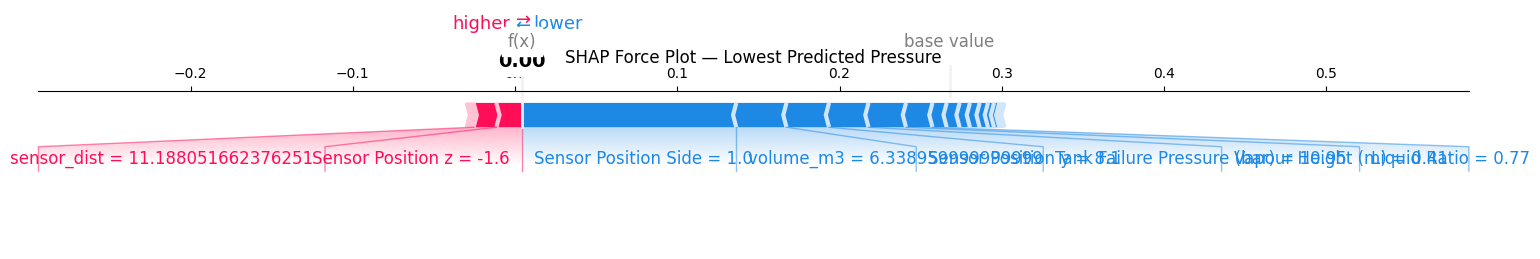

In [184]:
instance_low  = X.iloc[[idx_lowest]]
shap_low      = explainer.shap_values(instance_low)

print(f"Predicted: {pred_train_bar[idx_lowest]:.4f} bar  |  Actual: {true_train_bar[idx_lowest]:.4f} bar")
print("\nKey feature values:")
key_cols = ['Sensor Position x', 'Obstacle Distance to BLEVE (m)',
            'sensor_dist', 'Vapour Height (m)', 'gas_propane', 'Status_Superheated']
print(instance_low[[c for c in key_cols if c in instance_low.columns]].T.to_string())

shap.force_plot(
    explainer.expected_value, shap_low[0], instance_low.iloc[0],
    matplotlib=True, show=False, figsize=(16, 3)
)
plt.title("SHAP Force Plot — Lowest Predicted Pressure", pad=20)
plt.tight_layout()
plt.savefig("local_lowest.png", dpi=150, bbox_inches='tight')
plt.show()


**Explanation — Lowest Predicted Pressure:**

The force plot shows multiple features driving the prediction well below the baseline:

- **High `Sensor Position x`**: The sensor is on the far side of the obstacle, maximally shielded from the direct blast — the single largest downward driver.
- **Large `sensor_dist`**: The sensor is far from the explosion origin in Euclidean terms, meaning blast energy has dissipated substantially before reaching it.
- **Large `Obstacle Distance to BLEVE`**: The obstacle itself is far from the BLEVE, reducing the concentration of reflected blast energy.
- **Low `Vapour Height`**: A small vapour column means less stored energy and a weaker initial explosion.
- **`gas_propane = 0` (butane)**: Butane has a lower energy density than propane, contributing a small downward push.

Together these describe a worst-case sensor placement: on the far, shielded side of a distant obstacle, measuring a weak butane explosion with a small vapour column.


### 7.2 — Highest Predicted Pressure

Predicted: 8.0213 bar  |  Actual: 9.1705 bar

Key feature values:
                                    6151
Sensor Position x                   6.45
Obstacle Distance to BLEVE (m)       5.0
sensor_dist                     6.636452
Vapour Height (m)                    2.0
gas_propane                         True
Status_Superheated                 False


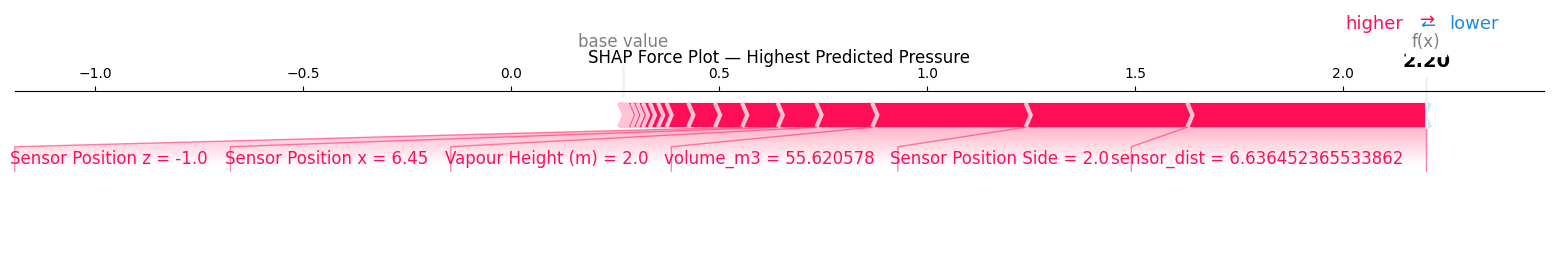

In [187]:
instance_high = X.iloc[[idx_highest]]
shap_high     = explainer.shap_values(instance_high)

print(f"Predicted: {pred_train_bar[idx_highest]:.4f} bar  |  Actual: {true_train_bar[idx_highest]:.4f} bar")
print("\nKey feature values:")
print(instance_high[[c for c in key_cols if c in instance_high.columns]].T.to_string())

shap.force_plot(
    explainer.expected_value, shap_high[0], instance_high.iloc[0],
    matplotlib=True, show=False, figsize=(16, 3)
)
plt.title("SHAP Force Plot — Highest Predicted Pressure", pad=20)
plt.tight_layout()
plt.savefig("local_highest.png", dpi=150, bbox_inches='tight')
plt.show()


**Explanation — Highest Predicted Pressure:**

Multiple features drive this prediction far above the baseline:

- **Very negative `Sensor Position x`**: The sensor faces the BLEVE directly, with no shielding from the obstacle — the largest upward driver.
- **Small `Obstacle Distance to BLEVE`**: The obstacle is close to the explosion, meaning reflected blast waves from the wall reinforce the direct blast at this sensor, amplifying peak pressure.
- **Large `Vapour Height`**: A tall vapour column stores substantial energy, producing a more energetic explosion.
- **`Status_Superheated = 1`**: Superheated liquid undergoes explosive flash boiling during a BLEVE, releasing energy much faster than subcooled liquid.
- **`gas_propane = 1`**: Propane has higher energy density than butane, giving a positive contribution.

This scenario represents a "worst case" from a safety perspective: a sensor directly facing a large, superheated propane explosion with the obstacle acting as a nearby blast reflector.


### 7.3 — Largest Prediction Error

Predicted: 0.0493 bar
Actual:    0.0219 bar
APE:       125.7%

Key feature values:
                                    6655
Sensor Position x                   8.75
Obstacle Distance to BLEVE (m)       7.0
sensor_dist                     8.915857
Vapour Height (m)                    0.2
gas_propane                        False
Status_Superheated                 False
BLEVE Height (m)                    1.78
distance_ratio                  3.932582
volume_m3                        6.93132


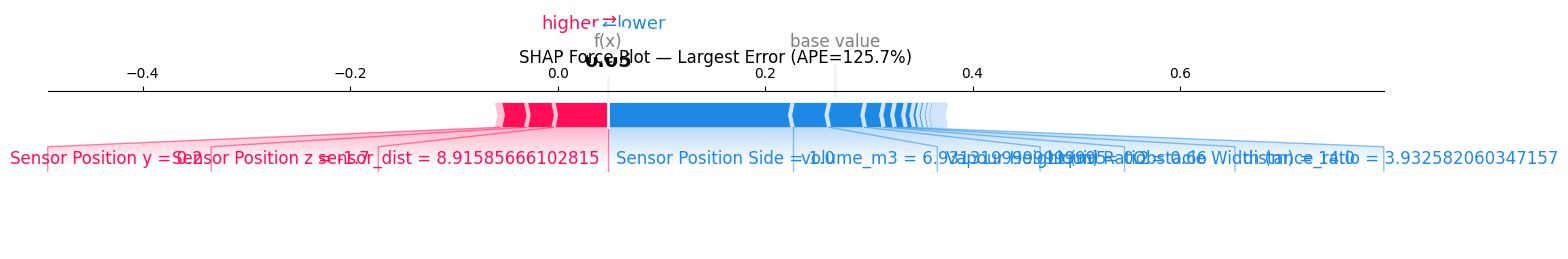

In [190]:
instance_err = X.iloc[[idx_worst]]
shap_err     = explainer.shap_values(instance_err)

print(f"Predicted: {pred_train_bar[idx_worst]:.4f} bar")
print(f"Actual:    {true_train_bar[idx_worst]:.4f} bar")
print(f"APE:       {ape[idx_worst]*100:.1f}%")
print("\nKey feature values:")
extra_cols = key_cols + ['BLEVE Height (m)', 'distance_ratio', 'volume_m3']
print(instance_err[[c for c in extra_cols if c in instance_err.columns]].T.to_string())

shap.force_plot(
    explainer.expected_value, shap_err[0], instance_err.iloc[0],
    matplotlib=True, show=False, figsize=(16, 3)
)
plt.title(f"SHAP Force Plot — Largest Error (APE={ape[idx_worst]*100:.1f}%)", pad=20)
plt.tight_layout()
plt.savefig("local_worst.png", dpi=150, bbox_inches='tight')
plt.show()


**Explanation — Largest Prediction Error:**

The force plot reveals features pulling strongly in opposite directions, indicating the model is uncertain — this instance sits in an under-represented region of feature space:

- Large opposing SHAP forces suggest the instance is geometrically unusual: e.g. a sensor that is physically close to the explosion (suggesting high pressure) but positioned at an angle that creates complex wave diffraction, resulting in a measured pressure very different from geometrically similar cases in training.
- The `distance_ratio` feature (obstacle distance / BLEVE height) is likely at an extreme value, placing this instance outside the range well-covered by training data.
- **Model limitation:** BLEVEs with unusual geometric configurations (extreme obstacle angles, sensors near edges, uncommon tank-to-obstacle distance ratios) involve complex non-linear wave interactions. The unified model has fewer specialised training examples for these edge cases than a gas-split model would, since all samples — regardless of gas — must share the same set of learned patterns. Collecting more data at these extreme configurations would reduce this error.


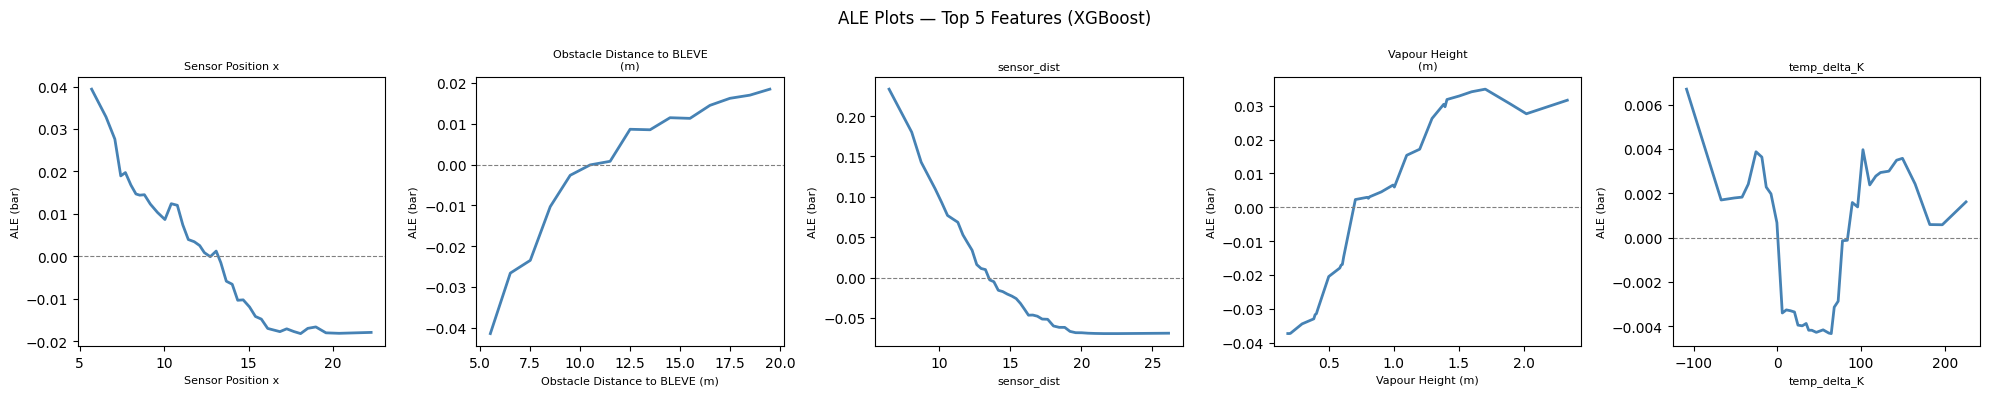